In [140]:
import torch.optim as optim
from src.utils import *
from src.algorithms import *
from src.losses import *
import deepinv as dinv
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from deepinv.models import DRUNet
from deepinv.optim.data_fidelity import L2
#from deepinv.optim.prior import PnP, ZeroPrior
from deepinv.optim import PGD
from deepinv.utils import load_example
from deepinv.utils.plotting import plot
from deepinv.optim.phase_retrieval import (
    correct_global_phase,
)
from deepinv.models.complex import to_complex_denoiser
from deepinv.optim.prior import PnP
import time
import numpy as np


BASE_DIR = Path(".")
RESULTS_DIR = BASE_DIR / "results"
# Set global random seed to ensure reproducibility.
torch.manual_seed(0)

import torch
import time
import numpy as np
import deepinv.optim.prior as prior

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [141]:
# Image size
img_size = 32
# The pixel values of the image are in the range [0, 1].
x = load_example(
    "SheppLogan.png",
    img_size=img_size,
    grayscale=True,
    resize_mode="resize",
    device=device,
)
print(x.min(), x.max())

tensor(0., device='cuda:0') tensor(0.7412, device='cuda:0')


In [142]:
x_phase = torch.exp(1j * x * torch.pi - 0.5j * torch.pi)

# Every element of the signal should have unit norm.
assert torch.allclose(x_phase.real**2 + x_phase.imag**2, torch.tensor(1.0))


In [143]:
# Define physics information
oversampling_ratio = 5.0
img_size = x.shape[1:]
m = int(oversampling_ratio * torch.prod(torch.tensor(img_size)))
n_channels = 1  # 3 for color images, 1 for gray-scale images

# Create the physics
physics = dinv.physics.RandomPhaseRetrieval(
    m=m,
    img_size=img_size,
    device=device,
)

# Generate measurements
y = physics(x_phase)

In [144]:
num_iter = 1000
x_true = x_phase.clone().detach()

[0] loss=99.5104  ||x_k-x*||^2=186.2121  lr=0.100000
[100] loss=0.4711  ||x_k-x*||^2=8.7153  lr=0.100000
[200] loss=0.0537  ||x_k-x*||^2=1.2290  lr=0.100000
[300] loss=0.0091  ||x_k-x*||^2=0.2324  lr=0.100000
[400] loss=0.0019  ||x_k-x*||^2=0.0509  lr=0.100000
[500] loss=0.0004  ||x_k-x*||^2=0.0121  lr=0.100000
[600] loss=0.0001  ||x_k-x*||^2=0.0031  lr=0.100000
[700] loss=0.0000  ||x_k-x*||^2=0.0008  lr=0.100000
[800] loss=0.0000  ||x_k-x*||^2=0.0002  lr=0.100000
[900] loss=0.0000  ||x_k-x*||^2=0.0001  lr=0.100000
GD initial loss: 99.510368
GD final loss:   0.000001
GD total time:   2.0368 sec
GD avg/iter:     0.002037 sec


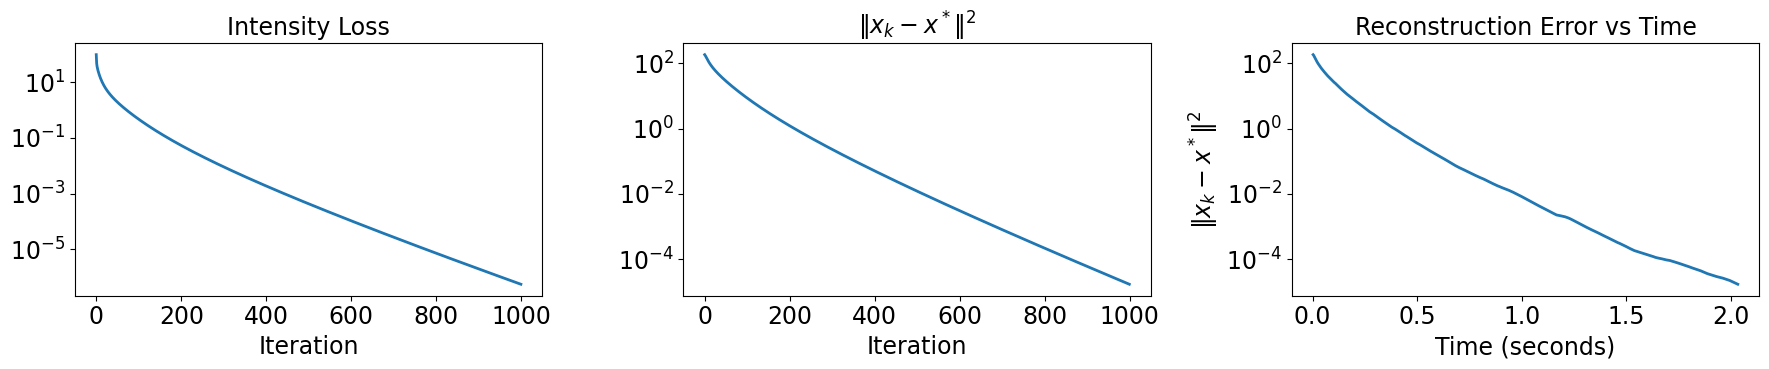

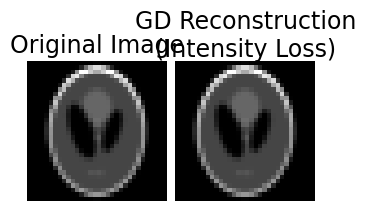

GD Final Loss:          0.000001
GD Final ||x_k-x*||^2:  0.000017


In [145]:
x_init = physics.A_dagger(y, n_iter=300)


if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

result_gd = gradient_descent_phase_retrieval(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    step_mode="constant",
    step_size=1e-1,
    loss_type="intensity"
)


if torch.cuda.is_available():
    torch.cuda.synchronize()
end_time = time.perf_counter()

loss_hist = result_gd["loss_hist"]
recon_error_hist = result_gd["recon_error_hist"]
time_hist = result_gd["time_hist"]
x_final = result_gd["x_final"]

total_time = end_time - start_time
avg_time = total_time / num_iter

print_run_summary(loss_hist, total_time, avg_time, method_name="GD")

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_gd_corrected = correct_global_phase(x_final, x_true)
x_gd_recon = torch.angle(x_gd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_gd_recon,
    title_recon="GD Reconstruction (Intensity Loss)"
)

final_recon_error = print_final_metrics(
    x_gd_corrected,
    x_true,
    loss_hist,
    method_name="GD"
)

[0] loss=29.2593  ||x_k-x*||^2=193.5654  lr=0.100000
[100] loss=1.2520  ||x_k-x*||^2=52.8799  lr=0.100000
[200] loss=0.4536  ||x_k-x*||^2=22.9832  lr=0.100000
[300] loss=0.1932  ||x_k-x*||^2=11.2180  lr=0.100000
[400] loss=0.0916  ||x_k-x*||^2=5.8487  lr=0.100000
[500] loss=0.0432  ||x_k-x*||^2=3.1836  lr=0.100000
[600] loss=0.0242  ||x_k-x*||^2=1.8055  lr=0.100000
[700] loss=0.0139  ||x_k-x*||^2=1.0560  lr=0.100000
[800] loss=0.0076  ||x_k-x*||^2=0.6302  lr=0.100000
[900] loss=0.0048  ||x_k-x*||^2=0.3828  lr=0.100000
SGD initial loss: 29.259277
SGD final loss:   0.003025
SGD total time:   2.6313 sec
SGD avg/iter:     0.002631 sec


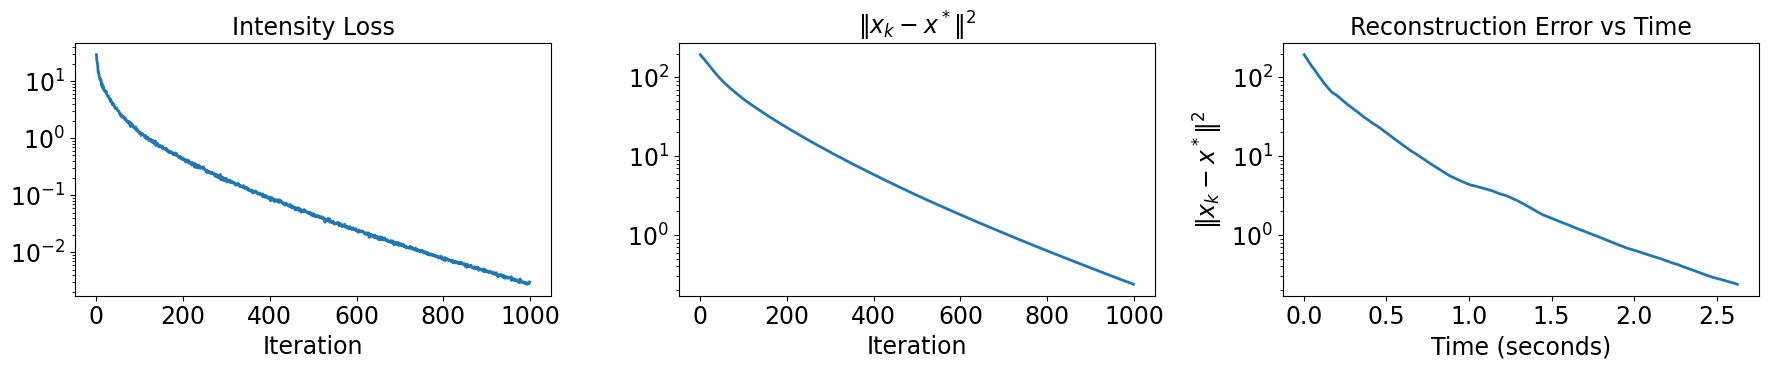

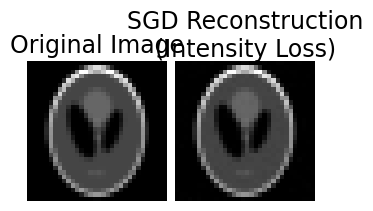

SGD Final Loss:          0.003025
SGD Final ||x_k-x*||^2:  0.237476


In [146]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_sgd = stochastic_gradient_descent_torch(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    step_size=1e-1,
    batch_ratio=0.3,
    step_mode="constant",
    loss_type="intensity",
    optimizer_type="sgd",
    momentum=0.0,
    verbose=True
)

loss_hist = result_sgd["loss_hist"]
recon_error_hist = result_sgd["recon_error_hist"]
time_hist = result_sgd["time_hist"]
x_final = result_sgd["x_final"]

print_run_summary(
    loss_hist,
    result_sgd["total_time"],
    result_sgd["avg_time"],
    method_name="SGD"
)

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_sgd_corrected = correct_global_phase(x_final, x_true)
x_sgd_recon = torch.angle(x_sgd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_sgd_recon,
    title_recon="SGD Reconstruction (Intensity Loss)"
)

final_recon_error = print_final_metrics(
    x_sgd_corrected,
    x_true,
    loss_hist,
    method_name="SGD"
)

[0] intensity_loss=99.1113  ||x_k-x*||^2=185.8308  lr=1.000000e-01
[100] intensity_loss=0.0001  ||x_k-x*||^2=0.0017  lr=3.660323e-02
[200] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.339797e-02
[300] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=4.904089e-03
[400] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.795055e-03
[500] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=6.570483e-04
[600] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=2.405009e-04
[700] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=8.803112e-05
[800] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=3.222224e-05
[900] intensity_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.179438e-05
AGD initial loss: 99.111328
AGD final loss:   0.000000
AGD total time:   2.7416 sec
AGD avg/iter:     0.002742 sec


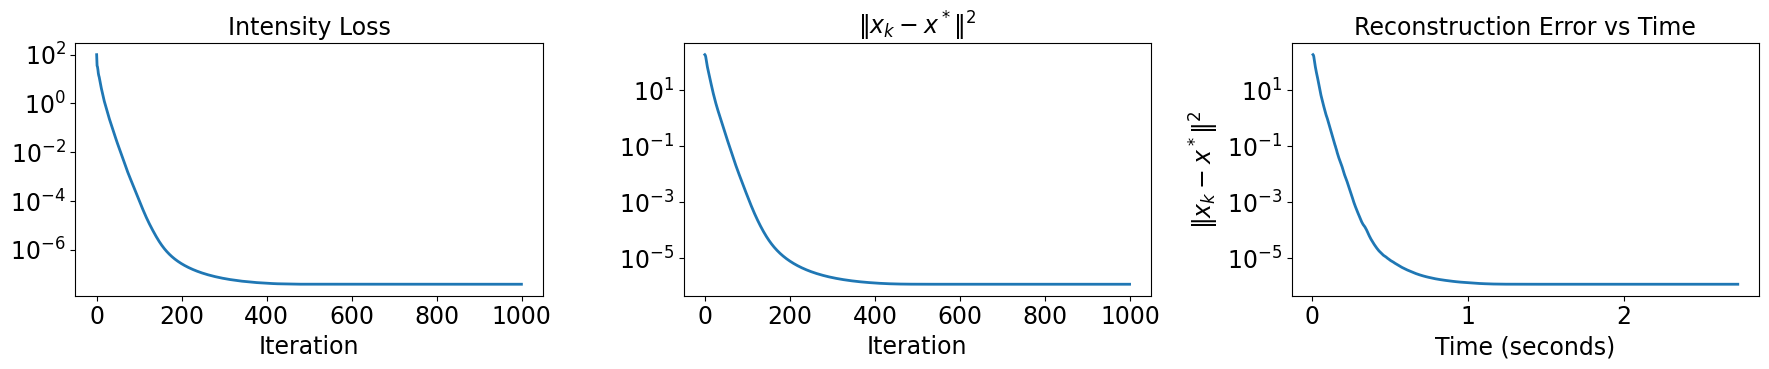

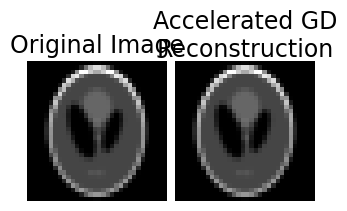

AGD Final Loss:          0.000000
AGD Final ||x_k-x*||^2:  0.000001


In [147]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_agd = accelerated_gradient_descent(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    step_mode="exp_decay",
    initial_lr=1e-1,
    decay_rate=0.99,
    beta=0.9,
    loss_type="intensity"
)

loss_hist = result_agd["loss_hist"]
recon_error_hist = result_agd["recon_error_hist"]
time_hist = result_agd["time_hist"]
x_final = result_agd["x_final"]

print_run_summary(
    loss_hist,
    result_agd["total_time"],
    result_agd["avg_time"],
    method_name="AGD"
)

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_agd_corrected = correct_global_phase(x_final, x_true)
x_agd_recon = torch.angle(x_agd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_agd_recon,
    title_recon="Accelerated GD Reconstruction"
)

final_recon_error = print_final_metrics(
    x_agd_corrected,
    x_true,
    loss_hist,
    method_name="AGD"
)


[0] intensity_loss=99.3402  ||x_k-x*||^2=196.8426
[100] intensity_loss=4.0924  ||x_k-x*||^2=49.4723
[200] intensity_loss=0.6616  ||x_k-x*||^2=10.9833
[300] intensity_loss=0.1157  ||x_k-x*||^2=2.3128
[400] intensity_loss=0.0212  ||x_k-x*||^2=0.4743
[500] intensity_loss=0.0038  ||x_k-x*||^2=0.0915
[600] intensity_loss=0.0006  ||x_k-x*||^2=0.0163
[700] intensity_loss=0.0001  ||x_k-x*||^2=0.0026
[800] intensity_loss=0.0000  ||x_k-x*||^2=0.0004
[900] intensity_loss=0.0000  ||x_k-x*||^2=0.0000
Adam initial loss: 99.340164
Adam final loss:   0.000000
Adam total time:   2.7129 sec
Adam avg/iter:     0.002713 sec


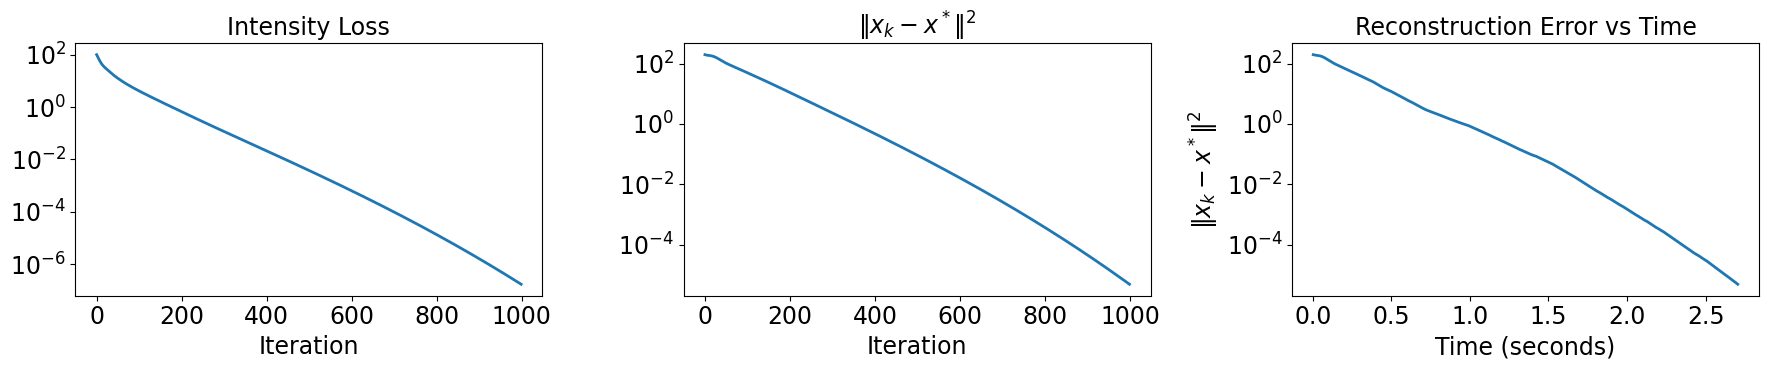

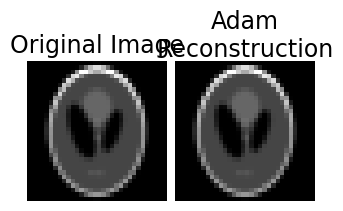

Adam Final Loss:          0.000000
Adam Final ||x_k-x*||^2:  0.000005


In [148]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_adam = adam(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    lr=1e-2,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    loss_type="intensity"
)

loss_hist = result_adam["loss_hist"]
recon_error_hist = result_adam["recon_error_hist"]
time_hist = result_adam["time_hist"]
x_final = result_adam["x_final"]

print_run_summary(
    loss_hist,
    result_adam["total_time"],
    result_adam["avg_time"],
    method_name="Adam"
)

plot_metrics(
    loss_hist,
    recon_error_hist,
    time_hist,
    loss_name="Intensity Loss"
)

x_adam_corrected = correct_global_phase(x_final, x_true)
x_adam_recon = torch.angle(x_adam_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_adam_recon,
    title_recon="Adam Reconstruction"
)

final_recon_error = print_final_metrics(
    x_adam_corrected,
    x_true,
    loss_hist,
    method_name="Adam"
)

[0] loss=99.211060  ||x_k-x*||^2=186.372131
[20] loss=0.006604  ||x_k-x*||^2=0.072452
[40] loss=0.000001  ||x_k-x*||^2=0.000014
[60] loss=0.000000  ||x_k-x*||^2=0.000000
[80] loss=0.000000  ||x_k-x*||^2=0.000000
[100] loss=0.000000  ||x_k-x*||^2=0.000000
[120] loss=0.000000  ||x_k-x*||^2=0.000000
[140] loss=0.000000  ||x_k-x*||^2=0.000000
[160] loss=0.000000  ||x_k-x*||^2=0.000000
[180] loss=0.000000  ||x_k-x*||^2=0.000000
[200] loss=0.000000  ||x_k-x*||^2=0.000000
[220] loss=0.000000  ||x_k-x*||^2=0.000000
[240] loss=0.000000  ||x_k-x*||^2=0.000000
[260] loss=0.000000  ||x_k-x*||^2=0.000000
[280] loss=0.000000  ||x_k-x*||^2=0.000000
initial loss: 99.2110595703125
final loss: 7.857553496748437e-10
Total time: 3.6651 sec
Avg per iteration: 0.012217 sec


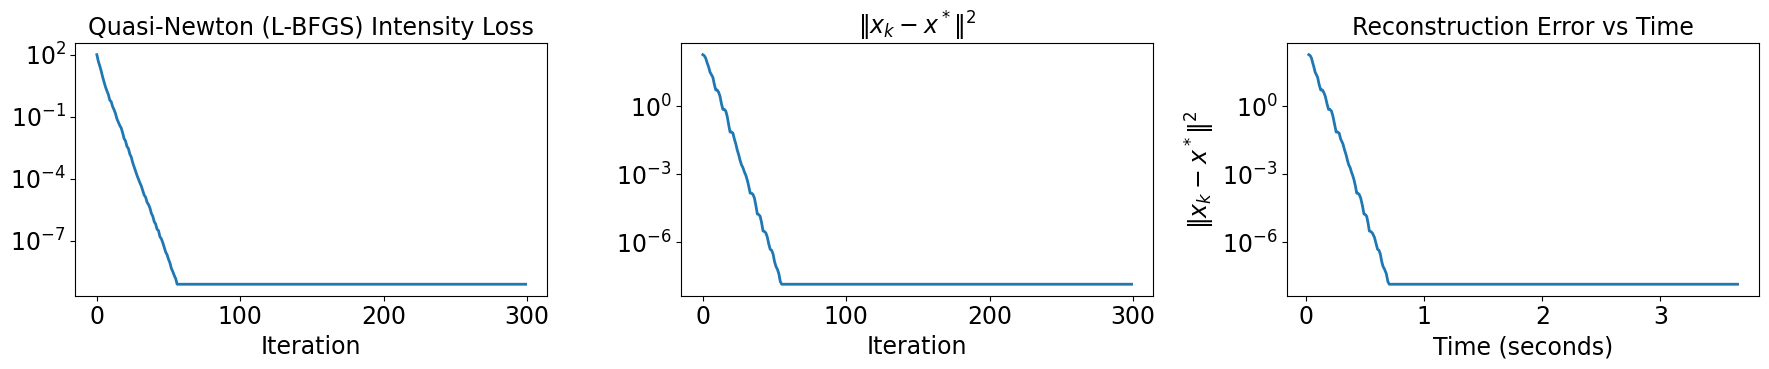

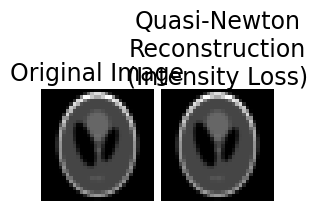

Quasi-Newton Final Loss:         0.000000
Quasi-Newton Final ||x_k-x*||^2: 0.000000


In [149]:
x_phase_qn = physics.A_dagger(y, n_iter=300).clone().detach()
x_phase_qn.requires_grad_(True)

x_true = x_phase.clone().detach()

num_iter = 300
loss_hist = []
recon_error_hist = []
time_hist = []

optimizer = torch.optim.LBFGS(
    [x_phase_qn],
    lr=1.0,
    max_iter=1,            
    history_size=10,
    line_search_fn="strong_wolfe" # None option
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

for i in range(num_iter):
    iter_start = time.perf_counter()

    def closure():
        optimizer.zero_grad()
        loss = intensity_loss(x_phase_qn, y, physics)
        loss.backward()
        return loss

    loss = optimizer.step(closure)

    with torch.no_grad():
        x_corrected = correct_global_phase(x_phase_qn.clone(), x_true)
        recon_error = torch.sum(torch.abs(x_corrected - x_true) ** 2).item()
        recon_error_hist.append(recon_error)
        loss_hist.append(loss.item())

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    iter_end = time.perf_counter()
    time_hist.append(iter_end - iter_start)

    if i % 20 == 0:
        print(f"[{i}] loss={loss_hist[-1]:.6f}  ||x_k-x*||^2={recon_error_hist[-1]:.6f}")

if torch.cuda.is_available():
    torch.cuda.synchronize()
end_time = time.perf_counter()

total_time = end_time - start_time
avg_time = total_time / num_iter

print("initial loss:", loss_hist[0])
print("final loss:", loss_hist[-1])
print(f"Total time: {total_time:.4f} sec")
print(f"Avg per iteration: {avg_time:.6f} sec")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(loss_hist)
axes[0].set_yscale("log")
axes[0].set_title("Quasi-Newton (L-BFGS) Intensity Loss")
axes[0].set_xlabel("Iteration")

axes[1].plot(recon_error_hist)
axes[1].set_yscale("log")
axes[1].set_title(r"$\|x_k - x^*\|^2$")
axes[1].set_xlabel("Iteration")

cumulative_time = np.cumsum(time_hist)
axes[2].plot(cumulative_time, recon_error_hist)
axes[2].set_yscale("log")
axes[2].set_title("Reconstruction Error vs Time")
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel(r"$\|x_k - x^*\|^2$")

plt.tight_layout()
plt.show()

x_qn_corrected = correct_global_phase(x_phase_qn.detach(), x_true)
x_qn_recon = torch.angle(x_qn_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot(
    [x_true_vis, x_qn_recon],
    titles=["Original Image", "Quasi-Newton Reconstruction (Intensity Loss)"],
    rescale_mode="clip"
)

final_recon_error = torch.sum(torch.abs(x_qn_corrected - x_true) ** 2).item()
print(f"Quasi-Newton Final Loss:         {loss_hist[-1]:.6f}")
print(f"Quasi-Newton Final ||x_k-x*||^2: {final_recon_error:.6f}")

result_qn = {
    "x_final": x_phase_qn.detach(),
    "loss_hist": loss_hist,
    "recon_error_hist": recon_error_hist,
    "time_hist": time_hist,
    "total_time": total_time,
    "avg_time": avg_time,
}

[0] intensity_loss=99.289566  beta=0.000000  alpha=2.500e-01  ||x_k-x*||^2=208.201370
[20] intensity_loss=0.031842  beta=0.780196  alpha=5.000e-01  ||x_k-x*||^2=0.243200
[40] intensity_loss=0.000041  beta=0.000000  alpha=5.000e-01  ||x_k-x*||^2=0.000917
[60] intensity_loss=0.000000  beta=0.000000  alpha=2.500e-01  ||x_k-x*||^2=0.000001
[80] intensity_loss=0.000000  beta=0.000000  alpha=5.000e-01  ||x_k-x*||^2=0.000000
[100] intensity_loss=0.000000  beta=1.299894  alpha=6.250e-02  ||x_k-x*||^2=0.000000
[120] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[140] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[160] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[180] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[200] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[220] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k

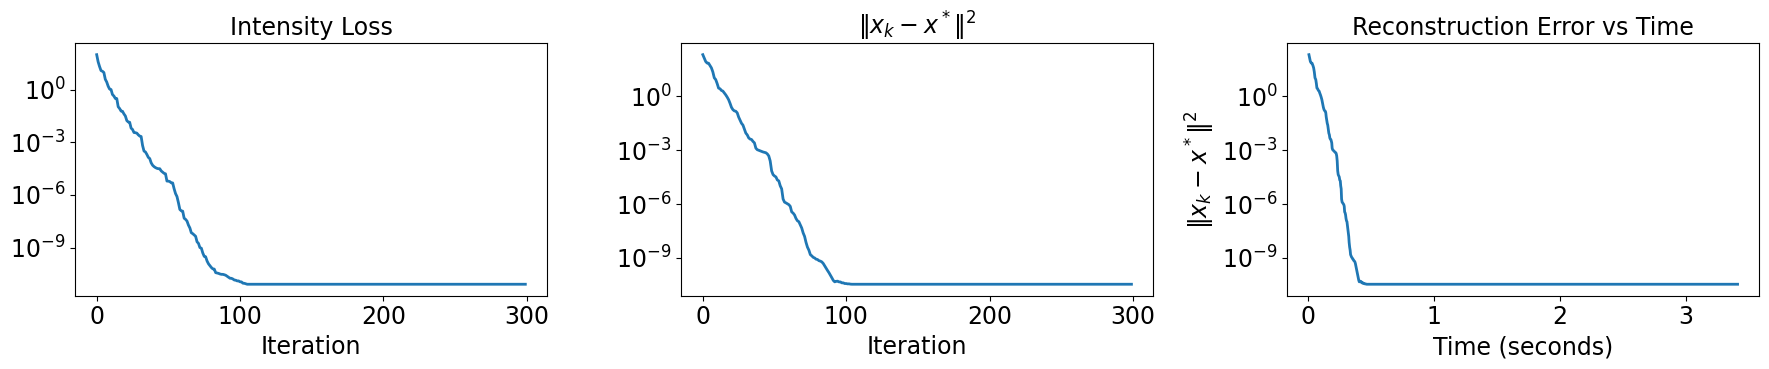

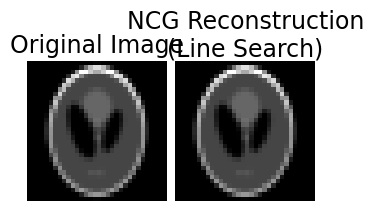

NCG+LS Final Loss:          0.000000
NCG+LS Final ||x_k-x*||^2:  0.000000


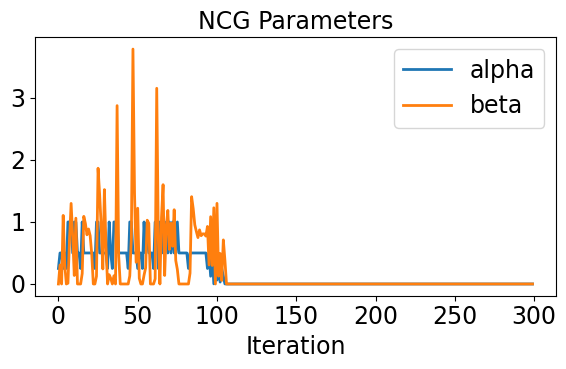

In [150]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()
x_true = x_phase.clone().detach()

result_ncg = nonlinear_conjugate_gradient(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=300,
    loss_type="intensity",
    beta_type="PR+",
    alpha0=1.0,
    rho=0.5,
    c=1e-4,
    min_alpha=1e-8,
    max_ls_steps=20,
    verbose=True
)

loss_hist = result_ncg["loss_hist"]
recon_error_hist = result_ncg["recon_error_hist"]
time_hist = result_ncg["time_hist"]
alpha_hist = result_ncg["alpha_hist"]
beta_hist = result_ncg["beta_hist"]
x_final = result_ncg["x_final"]

print_run_summary(
    loss_hist,
    result_ncg["total_time"],
    result_ncg["avg_time"],
    method_name="NCG+LS"
)

plot_metrics(
    loss_hist,
    recon_error_hist,
    time_hist,
    loss_name="Intensity Loss"
)

x_ncg_corrected = correct_global_phase(x_final, x_true)
x_ncg_recon = torch.angle(x_ncg_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_ncg_recon,
    title_recon="NCG Reconstruction (Line Search)"
)

final_recon_error = print_final_metrics(
    x_ncg_corrected,
    x_true,
    loss_hist,
    method_name="NCG+LS"
)

plt.figure(figsize=(6,4))
plt.plot(alpha_hist, label="alpha")
plt.plot(beta_hist, label="beta")
plt.xlabel("Iteration")
plt.title("NCG Parameters")
plt.legend()
plt.tight_layout()
plt.show()

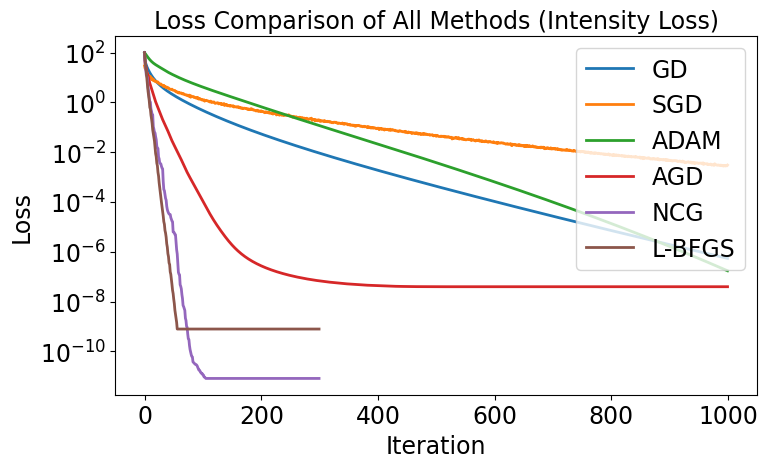

In [151]:
plt.figure(figsize=(8,5))

plt.plot(result_gd["loss_hist"], label="GD")
plt.plot(result_sgd["loss_hist"], label="SGD")
plt.plot(result_adam["loss_hist"], label="ADAM")
plt.plot(result_agd["loss_hist"], label="AGD")
plt.plot(result_ncg["loss_hist"], label="NCG")
plt.plot(result_qn["loss_hist"], label="L-BFGS")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Comparison of All Methods (Intensity Loss)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

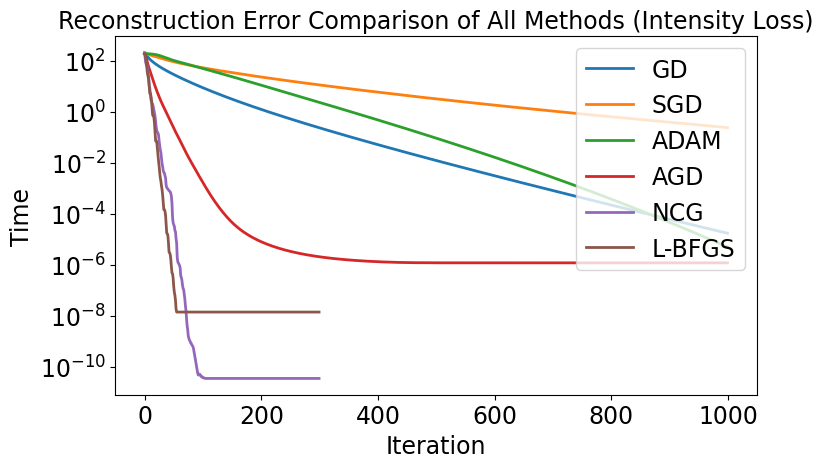

In [152]:
plt.figure(figsize=(8,5))

plt.plot(result_gd["recon_error_hist"], label="GD")
plt.plot(result_sgd["recon_error_hist"], label="SGD")
plt.plot(result_adam["recon_error_hist"], label="ADAM")
plt.plot(result_agd["recon_error_hist"], label="AGD")
plt.plot(result_ncg["recon_error_hist"], label="NCG")
plt.plot(result_qn["recon_error_hist"], label="L-BFGS")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Time")
plt.title("Reconstruction Error Comparison of All Methods (Intensity Loss)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

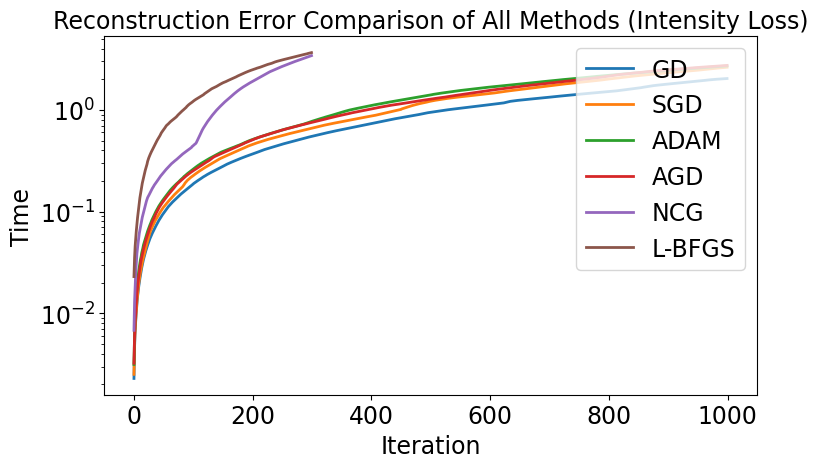

In [153]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(result_gd["time_hist"]), label="GD")
plt.plot(np.cumsum(result_sgd["time_hist"]), label="SGD")
plt.plot(np.cumsum(result_adam["time_hist"]), label="ADAM")
plt.plot(np.cumsum(result_agd["time_hist"]), label="AGD")
plt.plot(np.cumsum(result_ncg["time_hist"]), label="NCG")
plt.plot(np.cumsum(result_qn["time_hist"]), label="L-BFGS")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Time")
plt.title("Reconstruction Error Comparison of All Methods (Intensity Loss)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

GD semi-log convergence estimate
Fit range         : [301, 1000]
slope             : -1.853118e-02
rho = exp(slope)  : 0.981639
C                 : 9.116088e+02
R^2               : 0.996957
ratio mean        : 0.981480
ratio median      : 0.981894
ratio std         : 0.002253
model             : e_k ≈ C * rho^k
GD semi-log convergence estimate
Fit range         : [301, 1000]
slope             : -5.462649e-03
rho = exp(slope)  : 0.994552
C                 : 5.091520e+01
R^2               : 0.997906
ratio mean        : 0.994500
ratio median      : 0.994629
ratio std         : 0.000630
model             : e_k ≈ C * rho^k
GD semi-log convergence estimate
Fit range         : [11, 150]
slope             : -9.628884e-02
rho = exp(slope)  : 0.908202
C                 : 3.723825e+01
R^2               : 0.991031
ratio mean        : 0.907480
ratio median      : 0.910244
ratio std         : 0.022705
model             : e_k ≈ C * rho^k
GD semi-log convergence estimate
Fit range         : [301, 1000

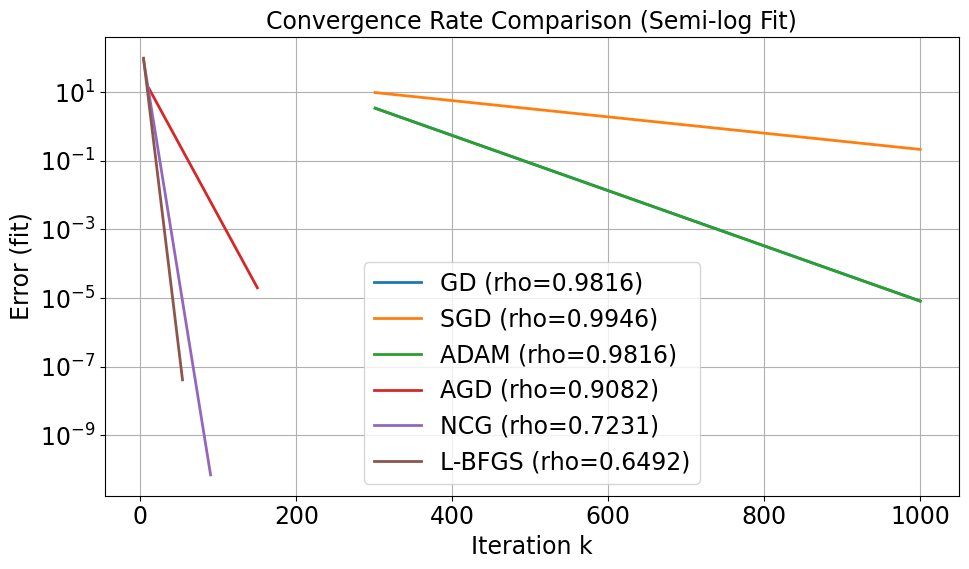

In [154]:
gd_rate = estimate_semilog_rate(
    error_hist=result_adam["recon_error_hist"],
    start_ratio=0.3,
    end_ratio=1,
    method_name="GD",
    plot=False
)

sgd_rate = estimate_semilog_rate(
    error_hist=result_sgd["recon_error_hist"],
    start_ratio=0.3,
    end_ratio=1,
    method_name="GD",
    plot=False
)

agd_rate = estimate_semilog_rate(
    error_hist=result_agd["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.15,
    method_name="GD",
    plot=False
)

adam_rate = estimate_semilog_rate(
    error_hist=result_adam["recon_error_hist"],
    start_ratio=0.3,
    end_ratio=1,
    method_name="GD",
    plot=False
)

qn_rate = estimate_semilog_rate(
    error_hist=result_qn["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.18,
    method_name="GD",
    plot=False
)

ncg_rate = estimate_semilog_rate(
    error_hist=result_ncg["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.3,
    method_name="GD",
    plot=False
)

plt.figure(figsize=(10,6))

plt.plot(gd_rate["k_fit"], gd_rate["y_fit"], label=f"GD (rho={gd_rate['rho']:.4f})")
plt.plot(sgd_rate["k_fit"], sgd_rate["y_fit"], label=f"SGD (rho={sgd_rate['rho']:.4f})")
plt.plot(adam_rate["k_fit"], adam_rate["y_fit"], label=f"ADAM (rho={adam_rate['rho']:.4f})")
plt.plot(agd_rate["k_fit"], agd_rate["y_fit"], label=f"AGD (rho={agd_rate['rho']:.4f})")
plt.plot(ncg_rate["k_fit"], ncg_rate["y_fit"], label=f"NCG (rho={ncg_rate['rho']:.4f})")
plt.plot(qn_rate["k_fit"], qn_rate["y_fit"], label=f"L-BFGS (rho={qn_rate['rho']:.4f})")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error (fit)")
plt.title("Convergence Rate Comparison (Semi-log Fit)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[0] loss=40.0631  ||x_k-x*||^2=189.5318  lr=0.100000
[100] loss=0.5942  ||x_k-x*||^2=9.5675  lr=0.100000
[200] loss=0.0520  ||x_k-x*||^2=1.0135  lr=0.100000
[300] loss=0.0066  ||x_k-x*||^2=0.1410  lr=0.100000
[400] loss=0.0010  ||x_k-x*||^2=0.0229  lr=0.100000
[500] loss=0.0002  ||x_k-x*||^2=0.0041  lr=0.100000
[600] loss=0.0000  ||x_k-x*||^2=0.0008  lr=0.100000
[700] loss=0.0000  ||x_k-x*||^2=0.0002  lr=0.100000
[800] loss=0.0000  ||x_k-x*||^2=0.0000  lr=0.100000
[900] loss=0.0000  ||x_k-x*||^2=0.0000  lr=0.100000
GD initial loss: 40.063141
GD final loss:   0.000000
GD total time:   3.6651 sec
GD avg/iter:     0.012217 sec


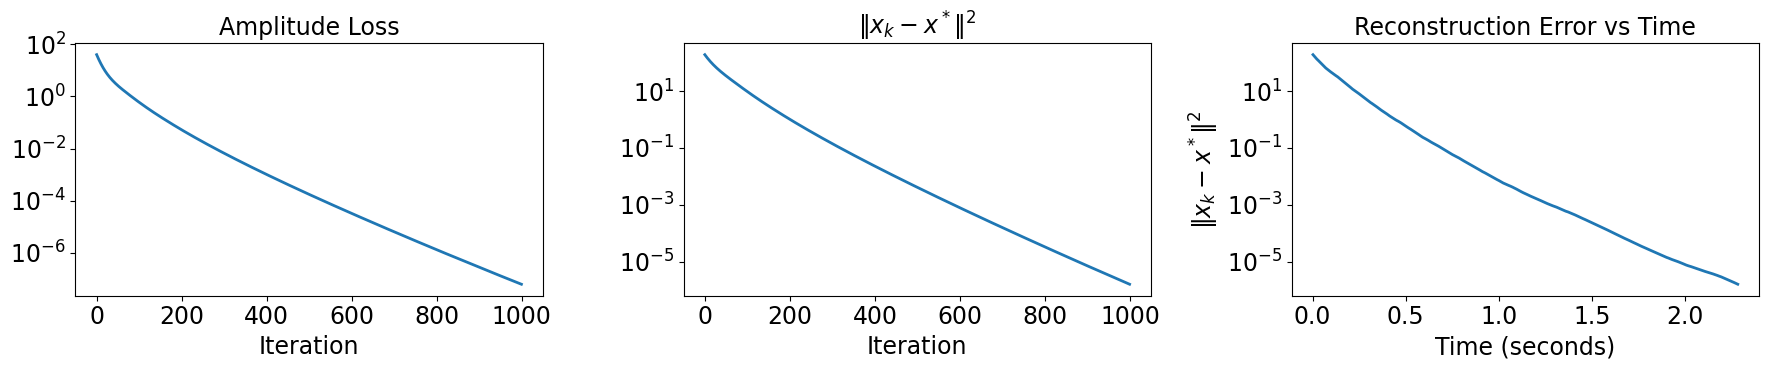

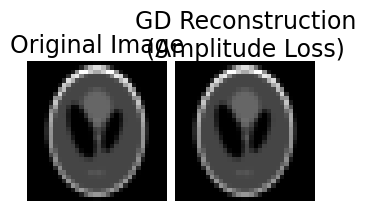

GD Final Loss:          0.000000
GD Final ||x_k-x*||^2:  0.000002


In [155]:
x_init = physics.A_dagger(y, n_iter=300)

result = gradient_descent_phase_retrieval(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    step_mode="constant",
    step_size=1e-1,
    loss_type="amplitude"
)

loss_hist = result["loss_hist"]
recon_error_hist = result["recon_error_hist"]
time_hist = result["time_hist"]
x_final = result["x_final"]

print_run_summary(loss_hist, total_time, avg_time, method_name="GD")

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Amplitude Loss")

x_gd_corrected = correct_global_phase(x_final, x_true)
x_gd_recon = torch.angle(x_gd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_gd_recon,
    title_recon="GD Reconstruction (Amplitude Loss)"
)

final_recon_error = print_final_metrics(
    x_gd_corrected,
    x_true,
    loss_hist,
    method_name="GD"
)

[0] loss=22.8145  ||x_k-x*||^2=193.7860  lr=0.100000
[100] loss=1.2048  ||x_k-x*||^2=26.6747  lr=0.100000
[200] loss=0.2121  ||x_k-x*||^2=5.9765  lr=0.100000
[300] loss=0.0458  ||x_k-x*||^2=1.5562  lr=0.100000
[400] loss=0.0135  ||x_k-x*||^2=0.4503  lr=0.100000
[500] loss=0.0040  ||x_k-x*||^2=0.1420  lr=0.100000
[600] loss=0.0012  ||x_k-x*||^2=0.0474  lr=0.100000
[700] loss=0.0004  ||x_k-x*||^2=0.0164  lr=0.100000
[800] loss=0.0001  ||x_k-x*||^2=0.0059  lr=0.100000
[900] loss=0.0001  ||x_k-x*||^2=0.0021  lr=0.100000
SGD initial loss: 22.814505
SGD final loss:   0.000021
SGD total time:   3.0647 sec
SGD avg/iter:     0.003065 sec


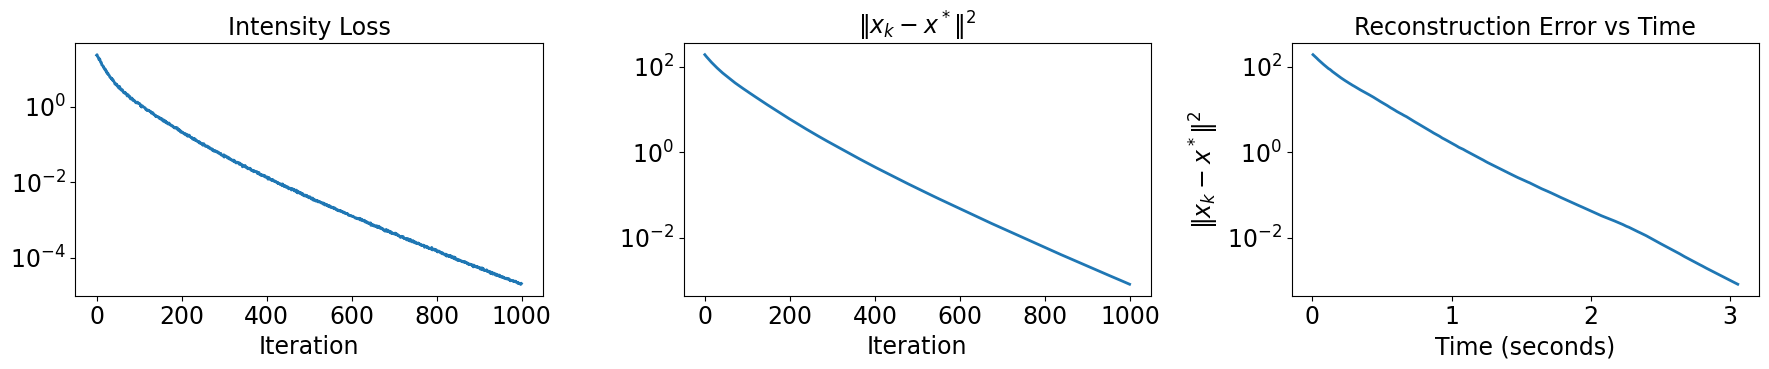

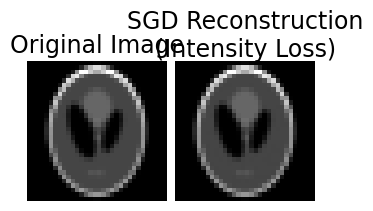

SGD Final Loss:          0.000021
SGD Final ||x_k-x*||^2:  0.000805


In [156]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_sgd = stochastic_gradient_descent_torch(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    step_size=1e-1,
    batch_ratio=0.3,
    step_mode="constant",
    loss_type="amplitude",
    optimizer_type="sgd",
    momentum=0.0,
    verbose=True
)

loss_hist = result_sgd["loss_hist"]
recon_error_hist = result_sgd["recon_error_hist"]
time_hist = result_sgd["time_hist"]
x_final = result_sgd["x_final"]

print_run_summary(
    loss_hist,
    result_sgd["total_time"],
    result_sgd["avg_time"],
    method_name="SGD"
)

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_sgd_corrected = correct_global_phase(x_final, x_true)
x_sgd_recon = torch.angle(x_sgd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_sgd_recon,
    title_recon="SGD Reconstruction (Intensity Loss)"
)

final_recon_error = print_final_metrics(
    x_sgd_corrected,
    x_true,
    loss_hist,
    method_name="SGD"
)

[0] amplitude_loss=40.0463  ||x_k-x*||^2=189.5601  lr=1.000000e-01
[100] amplitude_loss=0.0001  ||x_k-x*||^2=0.0020  lr=3.660323e-02
[200] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.339797e-02
[300] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=4.904089e-03
[400] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.795055e-03
[500] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=6.570483e-04
[600] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=2.405009e-04
[700] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=8.803112e-05
[800] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=3.222224e-05
[900] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000  lr=1.179438e-05
AGD initial loss: 40.046265
AGD final loss:   0.000000
AGD total time:   2.5341 sec
AGD avg/iter:     0.002534 sec


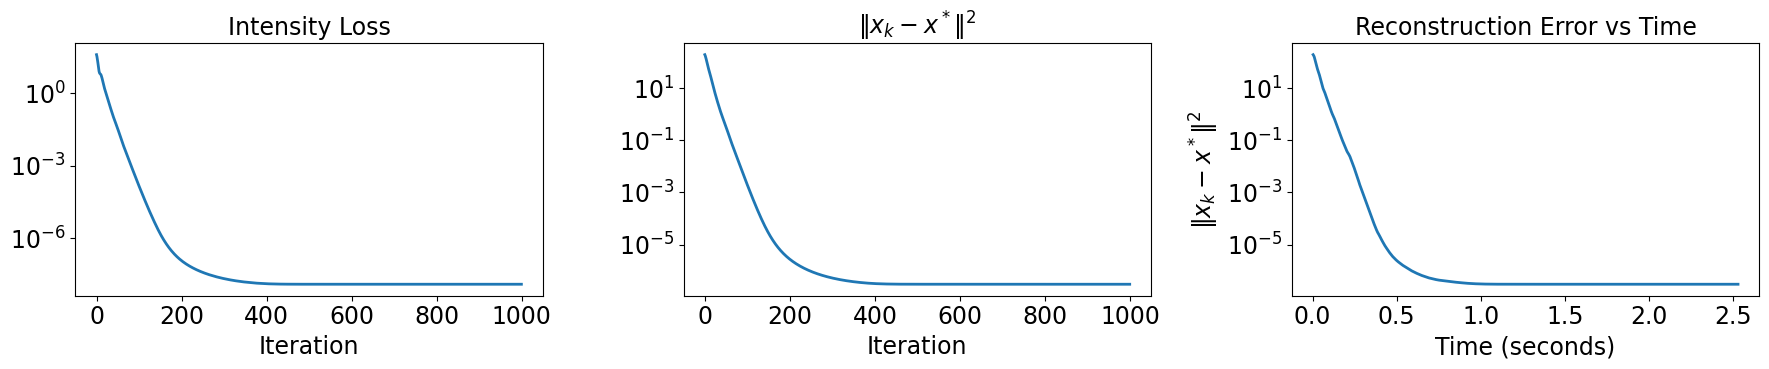

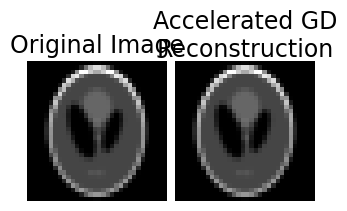

AGD Final Loss:          0.000000
AGD Final ||x_k-x*||^2:  0.000000


In [157]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_agd = accelerated_gradient_descent(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    step_mode="exp_decay",
    initial_lr=1e-1,
    decay_rate=0.99,
    beta=0.9,
    loss_type="amplitude"
)

loss_hist = result_agd["loss_hist"]
recon_error_hist = result_agd["recon_error_hist"]
time_hist = result_agd["time_hist"]
x_final = result_agd["x_final"]

print_run_summary(
    loss_hist,
    result_agd["total_time"],
    result_agd["avg_time"],
    method_name="AGD"
)

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_agd_corrected = correct_global_phase(x_final, x_true)
x_agd_recon = torch.angle(x_agd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_agd_recon,
    title_recon="Accelerated GD Reconstruction"
)

final_recon_error = print_final_metrics(
    x_agd_corrected,
    x_true,
    loss_hist,
    method_name="AGD"
)


[0] amplitude_loss=40.1154  ||x_k-x*||^2=194.8657
[100] amplitude_loss=0.9469  ||x_k-x*||^2=13.6532
[200] amplitude_loss=0.0253  ||x_k-x*||^2=0.4587
[300] amplitude_loss=0.0005  ||x_k-x*||^2=0.0097
[400] amplitude_loss=0.0000  ||x_k-x*||^2=0.0001
[500] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000
[600] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000
[700] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000
[800] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000
[900] amplitude_loss=0.0000  ||x_k-x*||^2=0.0000
Adam initial loss: 40.115425
Adam final loss:   0.000000
Adam total time:   3.1250 sec
Adam avg/iter:     0.003125 sec


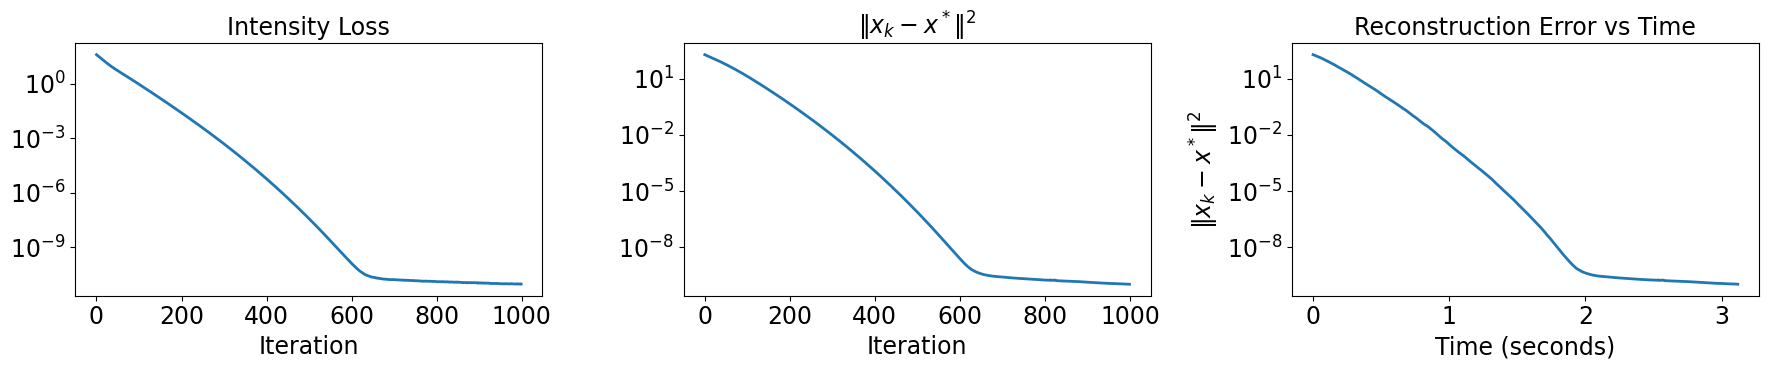

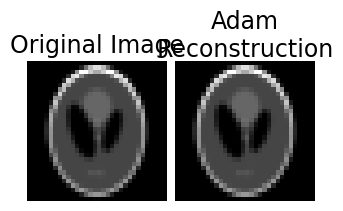

Adam Final Loss:          0.000000
Adam Final ||x_k-x*||^2:  0.000000


In [158]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_adam = adam(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    lr=1e-2,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    loss_type="amplitude"
)

loss_hist = result_adam["loss_hist"]
recon_error_hist = result_adam["recon_error_hist"]
time_hist = result_adam["time_hist"]
x_final = result_adam["x_final"]

print_run_summary(
    loss_hist,
    result_adam["total_time"],
    result_adam["avg_time"],
    method_name="Adam"
)

plot_metrics(
    loss_hist,
    recon_error_hist,
    time_hist,
    loss_name="Intensity Loss"
)

x_adam_corrected = correct_global_phase(x_final, x_true)
x_adam_recon = torch.angle(x_adam_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_adam_recon,
    title_recon="Adam Reconstruction"
)

final_recon_error = print_final_metrics(
    x_adam_corrected,
    x_true,
    loss_hist,
    method_name="Adam"
)

[0] loss=40.011013  ||x_k-x*||^2=175.278397
[20] loss=0.000004  ||x_k-x*||^2=0.000018
[40] loss=0.000000  ||x_k-x*||^2=0.000000
[60] loss=0.000000  ||x_k-x*||^2=0.000000
[80] loss=0.000000  ||x_k-x*||^2=0.000000
[100] loss=0.000000  ||x_k-x*||^2=0.000000
[120] loss=0.000000  ||x_k-x*||^2=0.000000
[140] loss=0.000000  ||x_k-x*||^2=0.000000
[160] loss=0.000000  ||x_k-x*||^2=0.000000
[180] loss=0.000000  ||x_k-x*||^2=0.000000
[200] loss=0.000000  ||x_k-x*||^2=0.000000
[220] loss=0.000000  ||x_k-x*||^2=0.000000
[240] loss=0.000000  ||x_k-x*||^2=0.000000
[260] loss=0.000000  ||x_k-x*||^2=0.000000
[280] loss=0.000000  ||x_k-x*||^2=0.000000
initial loss: 40.01101303100586
final loss: 8.078405722145021e-10
Total time: 2.5671 sec
Avg per iteration: 0.008557 sec


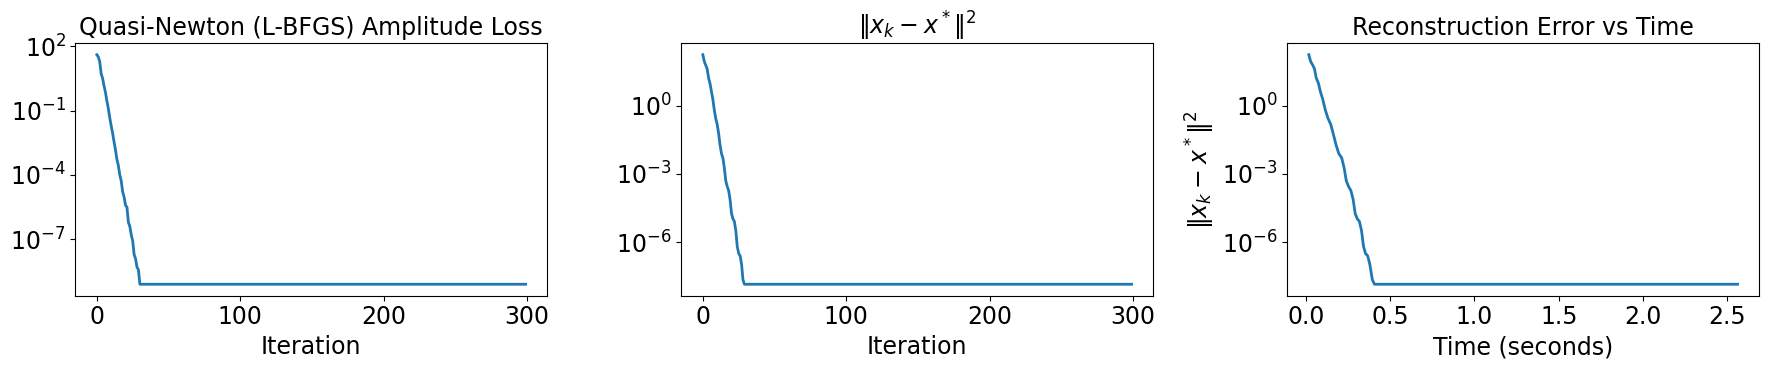

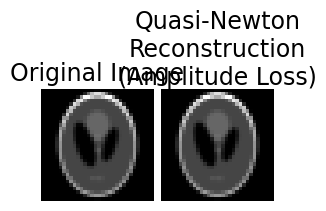

Quasi-Newton Final Loss:         0.000000
Quasi-Newton Final ||x_k-x*||^2: 0.000000


In [159]:
x_phase_qn = physics.A_dagger(y, n_iter=300).clone().detach()
x_phase_qn.requires_grad_(True)

x_true = x_phase.clone().detach()

num_iter = 300
loss_hist = []
recon_error_hist = []
time_hist = []

optimizer = torch.optim.LBFGS(
    [x_phase_qn],
    lr=1.0,
    max_iter=1,
    history_size=10,
    line_search_fn="strong_wolfe"   # None da olabilir
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

for i in range(num_iter):
    iter_start = time.perf_counter()

    def closure():
        optimizer.zero_grad()
        loss = amplitude_loss(x_phase_qn, y, physics)
        loss.backward()
        return loss

    loss = optimizer.step(closure)

    with torch.no_grad():
        x_corrected = correct_global_phase(x_phase_qn.clone(), x_true)
        recon_error = torch.sum(torch.abs(x_corrected - x_true) ** 2).item()
        recon_error_hist.append(recon_error)
        loss_hist.append(loss.item())

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    iter_end = time.perf_counter()
    time_hist.append(iter_end - iter_start)

    if i % 20 == 0:
        print(f"[{i}] loss={loss_hist[-1]:.6f}  ||x_k-x*||^2={recon_error_hist[-1]:.6f}")

if torch.cuda.is_available():
    torch.cuda.synchronize()
end_time = time.perf_counter()

total_time = end_time - start_time
avg_time = total_time / num_iter

print("initial loss:", loss_hist[0])
print("final loss:", loss_hist[-1])
print(f"Total time: {total_time:.4f} sec")
print(f"Avg per iteration: {avg_time:.6f} sec")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(loss_hist)
axes[0].set_yscale("log")
axes[0].set_title("Quasi-Newton (L-BFGS) Amplitude Loss")
axes[0].set_xlabel("Iteration")

axes[1].plot(recon_error_hist)
axes[1].set_yscale("log")
axes[1].set_title(r"$\|x_k - x^*\|^2$")
axes[1].set_xlabel("Iteration")

cumulative_time = np.cumsum(time_hist)
axes[2].plot(cumulative_time, recon_error_hist)
axes[2].set_yscale("log")
axes[2].set_title("Reconstruction Error vs Time")
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel(r"$\|x_k - x^*\|^2$")

plt.tight_layout()
plt.show()

x_qn_corrected = correct_global_phase(x_phase_qn.detach(), x_true)
x_qn_recon = torch.angle(x_qn_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot(
    [x_true_vis, x_qn_recon],
    titles=["Original Image", "Quasi-Newton Reconstruction (Amplitude Loss)"],
    rescale_mode="clip"
)

final_recon_error = torch.sum(torch.abs(x_qn_corrected - x_true) ** 2).item()
print(f"Quasi-Newton Final Loss:         {loss_hist[-1]:.6f}")
print(f"Quasi-Newton Final ||x_k-x*||^2: {final_recon_error:.6f}")


result_qn = {
    "x_final": x_phase_qn.detach(),
    "loss_hist": loss_hist,
    "recon_error_hist": recon_error_hist,
    "time_hist": time_hist,
    "total_time": total_time,
    "avg_time": avg_time,
}

[0] amplitude_loss=40.288189  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=130.916656
[20] amplitude_loss=0.050706  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.824723
[40] amplitude_loss=0.000868  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.016898
[60] amplitude_loss=0.000025  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.000516
[80] amplitude_loss=0.000001  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.000019
[100] amplitude_loss=0.000000  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.000001
[120] amplitude_loss=0.000000  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.000000
[140] amplitude_loss=0.000000  beta=0.118361  alpha=1.000e+00  ||x_k-x*||^2=0.000000
[160] amplitude_loss=0.000000  beta=0.271451  alpha=1.000e+00  ||x_k-x*||^2=0.000000
[180] amplitude_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[200] amplitude_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[220] amplitude_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k

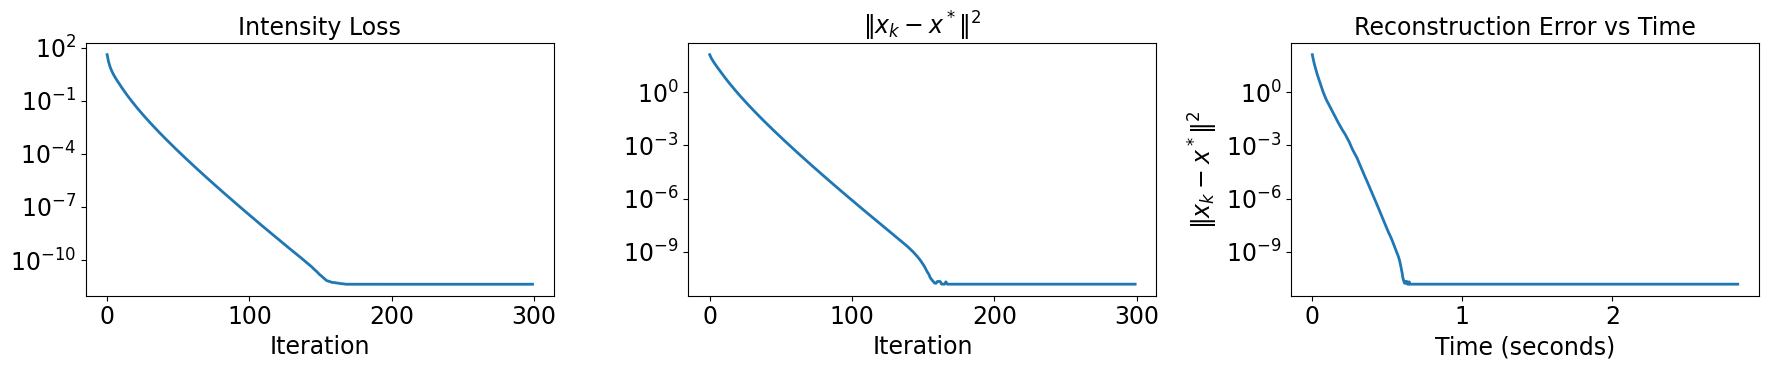

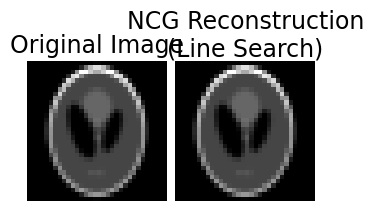

NCG+LS Final Loss:          0.000000
NCG+LS Final ||x_k-x*||^2:  0.000000


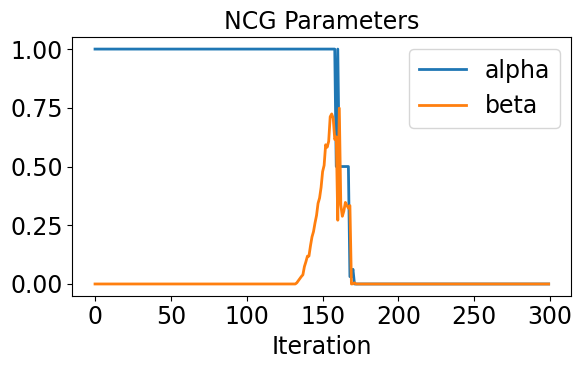

In [160]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()
x_true = x_phase.clone().detach()

result_ncg = nonlinear_conjugate_gradient(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=300,
    loss_type="amplitude",
    beta_type="PR+",
    alpha0=1.0,
    rho=0.5,
    c=1e-4,
    min_alpha=1e-8,
    max_ls_steps=20,
    verbose=True
)

loss_hist = result_ncg["loss_hist"]
recon_error_hist = result_ncg["recon_error_hist"]
time_hist = result_ncg["time_hist"]
alpha_hist = result_ncg["alpha_hist"]
beta_hist = result_ncg["beta_hist"]
x_final = result_ncg["x_final"]

print_run_summary(
    loss_hist,
    result_ncg["total_time"],
    result_ncg["avg_time"],
    method_name="NCG+LS"
)

plot_metrics(
    loss_hist,
    recon_error_hist,
    time_hist,
    loss_name="Intensity Loss"
)

x_ncg_corrected = correct_global_phase(x_final, x_true)
x_ncg_recon = torch.angle(x_ncg_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_ncg_recon,
    title_recon="NCG Reconstruction (Line Search)"
)

final_recon_error = print_final_metrics(
    x_ncg_corrected,
    x_true,
    loss_hist,
    method_name="NCG+LS"
)

plt.figure(figsize=(6,4))
plt.plot(alpha_hist, label="alpha")
plt.plot(beta_hist, label="beta")
plt.xlabel("Iteration")
plt.title("NCG Parameters")
plt.legend()
plt.tight_layout()
plt.show()

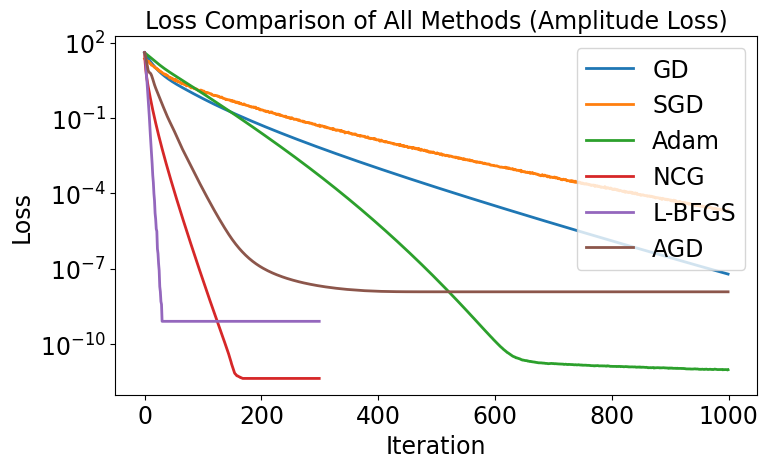

In [161]:
plt.figure(figsize=(8,5))

plt.plot(result["loss_hist"], label="GD")
plt.plot(result_sgd["loss_hist"], label="SGD")
plt.plot(result_adam["loss_hist"], label="Adam")
plt.plot(result_ncg["loss_hist"], label="NCG")
plt.plot(result_qn["loss_hist"], label="L-BFGS")
plt.plot(result_agd["loss_hist"], label="AGD")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Comparison of All Methods (Amplitude Loss)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

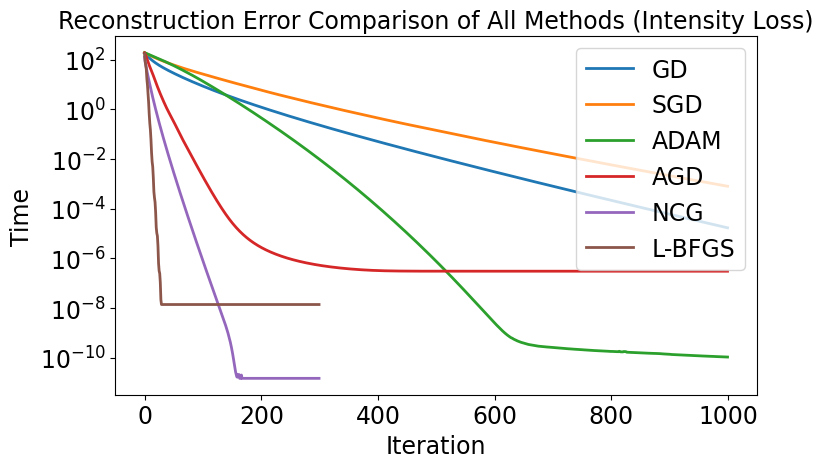

In [162]:
plt.figure(figsize=(8,5))

plt.plot(result_gd["recon_error_hist"], label="GD")
plt.plot(result_sgd["recon_error_hist"], label="SGD")
plt.plot(result_adam["recon_error_hist"], label="ADAM")
plt.plot(result_agd["recon_error_hist"], label="AGD")
plt.plot(result_ncg["recon_error_hist"], label="NCG")
plt.plot(result_qn["recon_error_hist"], label="L-BFGS")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Time")
plt.title("Reconstruction Error Comparison of All Methods (Intensity Loss)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

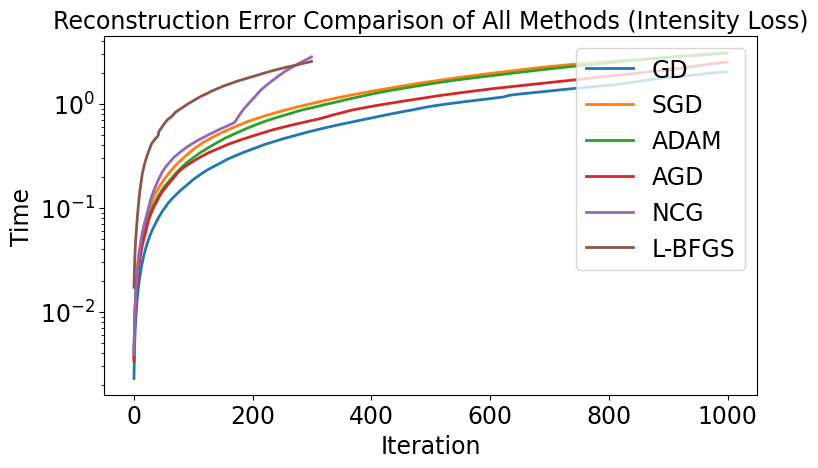

In [163]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(result_gd["time_hist"]), label="GD")
plt.plot(np.cumsum(result_sgd["time_hist"]), label="SGD")
plt.plot(np.cumsum(result_adam["time_hist"]), label="ADAM")
plt.plot(np.cumsum(result_agd["time_hist"]), label="AGD")
plt.plot(np.cumsum(result_ncg["time_hist"]), label="NCG")
plt.plot(np.cumsum(result_qn["time_hist"]), label="L-BFGS")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Time")
plt.title("Reconstruction Error Comparison of All Methods (Intensity Loss)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

GD semi-log convergence estimate
Fit range         : [301, 1000]
slope             : -2.705548e-02
rho = exp(slope)  : 0.973307
C                 : 8.598387e-01
R^2               : 0.833922
ratio mean        : 0.974387
ratio median      : 0.983767
ratio std         : 0.023041
model             : e_k ≈ C * rho^k
GD semi-log convergence estimate
Fit range         : [301, 1000]
slope             : -1.072789e-02
rho = exp(slope)  : 0.989329
C                 : 3.225966e+01
R^2               : 0.998930
ratio mean        : 0.989234
ratio median      : 0.989431
ratio std         : 0.000915
model             : e_k ≈ C * rho^k
GD semi-log convergence estimate
Fit range         : [11, 150]
slope             : -1.014639e-01
rho = exp(slope)  : 0.903514
C                 : 6.578124e+01
R^2               : 0.995876
ratio mean        : 0.902526
ratio median      : 0.904708
ratio std         : 0.016631
model             : e_k ≈ C * rho^k
GD semi-log convergence estimate
Fit range         : [301, 1000

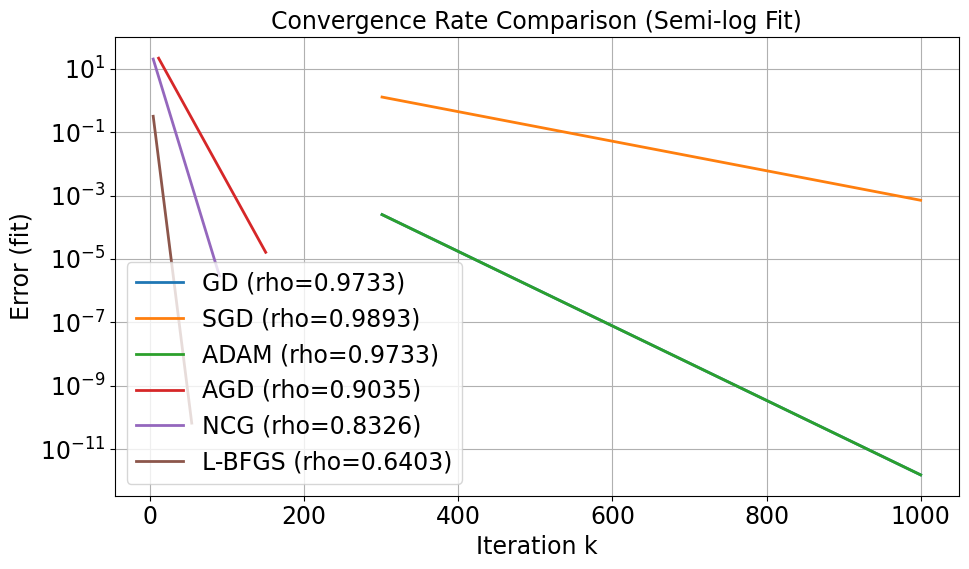

In [164]:
gd_rate = estimate_semilog_rate(
    error_hist=result_adam["recon_error_hist"],
    start_ratio=0.3,
    end_ratio=1,
    method_name="GD",
    plot=False
)

sgd_rate = estimate_semilog_rate(
    error_hist=result_sgd["recon_error_hist"],
    start_ratio=0.3,
    end_ratio=1,
    method_name="GD",
    plot=False
)

agd_rate = estimate_semilog_rate(
    error_hist=result_agd["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.15,
    method_name="GD",
    plot=False
)

adam_rate = estimate_semilog_rate(
    error_hist=result_adam["recon_error_hist"],
    start_ratio=0.3,
    end_ratio=1,
    method_name="GD",
    plot=False
)

qn_rate = estimate_semilog_rate(
    error_hist=result_qn["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.18,
    method_name="GD",
    plot=False
)

ncg_rate = estimate_semilog_rate(
    error_hist=result_ncg["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.3,
    method_name="GD",
    plot=False
)

plt.figure(figsize=(10,6))

plt.plot(gd_rate["k_fit"], gd_rate["y_fit"], label=f"GD (rho={gd_rate['rho']:.4f})")
plt.plot(sgd_rate["k_fit"], sgd_rate["y_fit"], label=f"SGD (rho={sgd_rate['rho']:.4f})")
plt.plot(adam_rate["k_fit"], adam_rate["y_fit"], label=f"ADAM (rho={adam_rate['rho']:.4f})")
plt.plot(agd_rate["k_fit"], agd_rate["y_fit"], label=f"AGD (rho={agd_rate['rho']:.4f})")
plt.plot(ncg_rate["k_fit"], ncg_rate["y_fit"], label=f"NCG (rho={ncg_rate['rho']:.4f})")
plt.plot(qn_rate["k_fit"], qn_rate["y_fit"], label=f"L-BFGS (rho={qn_rate['rho']:.4f})")

plt.yscale("log")
plt.xlabel("Iteration k")
plt.ylabel("Error (fit)")
plt.title("Convergence Rate Comparison (Semi-log Fit)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()